In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import scipy.stats as ss

**A. Calculate eigenvectors and eigenvalues by hand**

Using a very simple example with a best dataset




PearsonRResult(statistic=1.0, pvalue=0.0)


Text(0, 0.5, 'y')

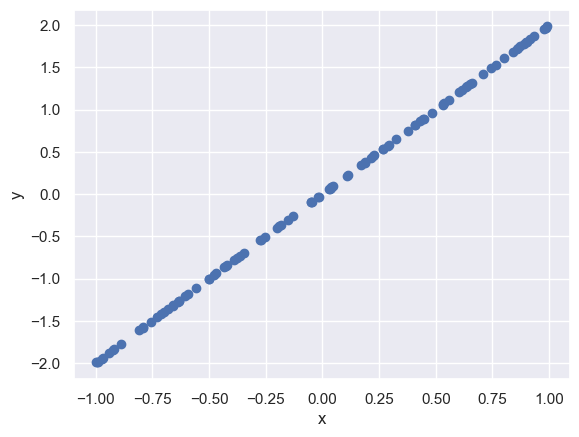

In [3]:
x = np.random.uniform(-1,1,100)
y = 2*x
plt.scatter(x,y)
print(ss.pearsonr(x,y))
plt.xlabel('x')
plt.ylabel('y')

1. Get the data matrix
2. Subtract the mean (optional)
3. Calculate covariance matrix

In [4]:
X_matrix = np.stack((x,y),axis=1)
print(len(X_matrix),len(X_matrix[0]))
#X_matrix[i,j] 

100 2


In [5]:
X_matrix[:,0]=X_matrix[:,0]-np.mean(X_matrix[:,0])
X_matrix[:,1]=X_matrix[:,1]-np.mean(X_matrix[:,1])
#print(X_matrix)

In [6]:
Covariance = np.cov(X_matrix.T)
print(Covariance)

[[0.36417162 0.72834323]
 [0.72834323 1.45668646]]


***Now, calculate the eigenvalues and eigenvectors by hand.***

What is the answer?





**B. Run PCA for this case**

1. Import PCA and run!

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X_matrix)

# input matrx[i,j] i Number of object j Number of features

PCA(n_components=2)

2. Eigenvectors as pca.components_

In [8]:
print('1st Eigenvector:',pca.components_[0])
print('2nd Eigenvector:',pca.components_[1])

1st Eigenvector: [-0.4472136  -0.89442719]
2nd Eigenvector: [ 0.89442719 -0.4472136 ]


3. Eigenvalues as pca.explained_variance_

In [9]:
print('Eigenvalues',pca.explained_variance_)
print('Explain variance',pca.explained_variance_ratio_)

Eigenvalues [1.82085808e+00 1.17168763e-32]
Explain variance [1.00000000e+00 6.43481028e-33]


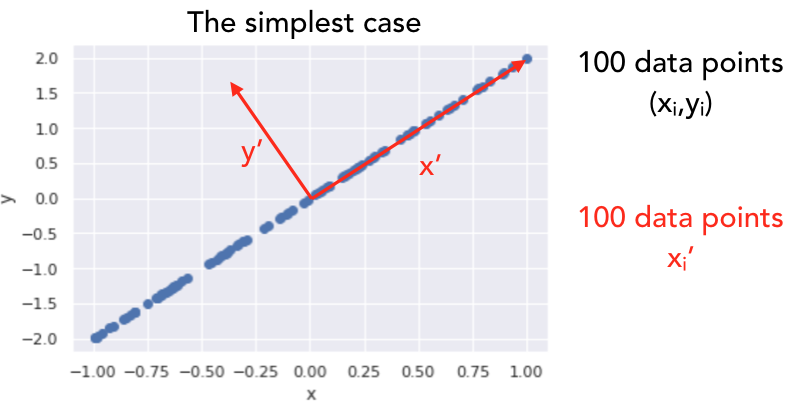

**The new xy values - coefficients**

The dot between original data and eigenvectors




In [11]:
new_x = np.dot(X_matrix,pca.components_[0])
new_y = np.dot(X_matrix,pca.components_[1])
print(X_matrix[1,:])
print(new_x[1],new_y[1])
#print(new_y)

[-0.67770751 -1.35541501]
1.5154000544249064 -1.1102230246251565e-16


In [12]:
coefficients = pca.transform(X_matrix)

In [13]:
coefficients[1,0]

1.5154000544249064

In [14]:
pca.components_[0]

array([-0.4472136 , -0.89442719])

**PCA can reconstruct the original dataset**

Very important to make sure we are doing right!

(x,y) = coefficient1 x eigenvector 1+ coefficient2 x eigenvector2

In [15]:
#x_reconstruct = np.arange(0,100)*0.0
#y_reconstruct = np.arange(0,100)*0.0
x_reconstruct = np.zeros((100,2))
for i_object in range(0,100):
    #x_reconstruct[i_object]=new_x[i_object]*pca.components_[0][0]+new_y[i_object]*pca.components_[1][0]
    #y_reconstruct[i_object]=new_x[i_object]*pca.components_[0][1]+new_y[i_object]*pca.components_[1][1]
    x_reconstruct[i_object]=coefficients[i_object,0]*pca.components_[0]+coefficients[i_object,1]*pca.components_[1]+pca.mean_


In [17]:
print(x_reconstruct[1])
print(X_matrix[1])

[-0.67770751 -1.35541501]
[-0.67770751 -1.35541501]


**Eigenvectors are orthogonal.**

In [18]:
np.dot(pca.components_[0],pca.components_[1])

0.0

**C. Exercise SDSS quasar spectra**

1. Download data https://drive.google.com/file/d/1bfZ5uCvZAFTJ67mdAges3Bd6VEne3qdM/view?usp=sharing

In [26]:
#from google.colab import drive
#drive.mount(dd'/content/gdrive', force_remount=True)
#root_dir = "/content/gdrive/My Drive/Colab Notebooks/"

In [19]:
import astropy.io.fits as pf
from sklearn.decomposition import  PCA
#dir_d = "/Users/tlan/Dropbox/Astro_Research/My_Classes/110_Fall/data_analysis_in_astronomy/code/Week_9/"
data = pf.open('clean_spectra.fits')
# data[0].data[N_object,N_pixel]
# data[2].data log_wavelength
wavelength = 10**data[2].data

In [20]:
len(wavelength)

2483

Text(0, 0.5, 'Flux []')

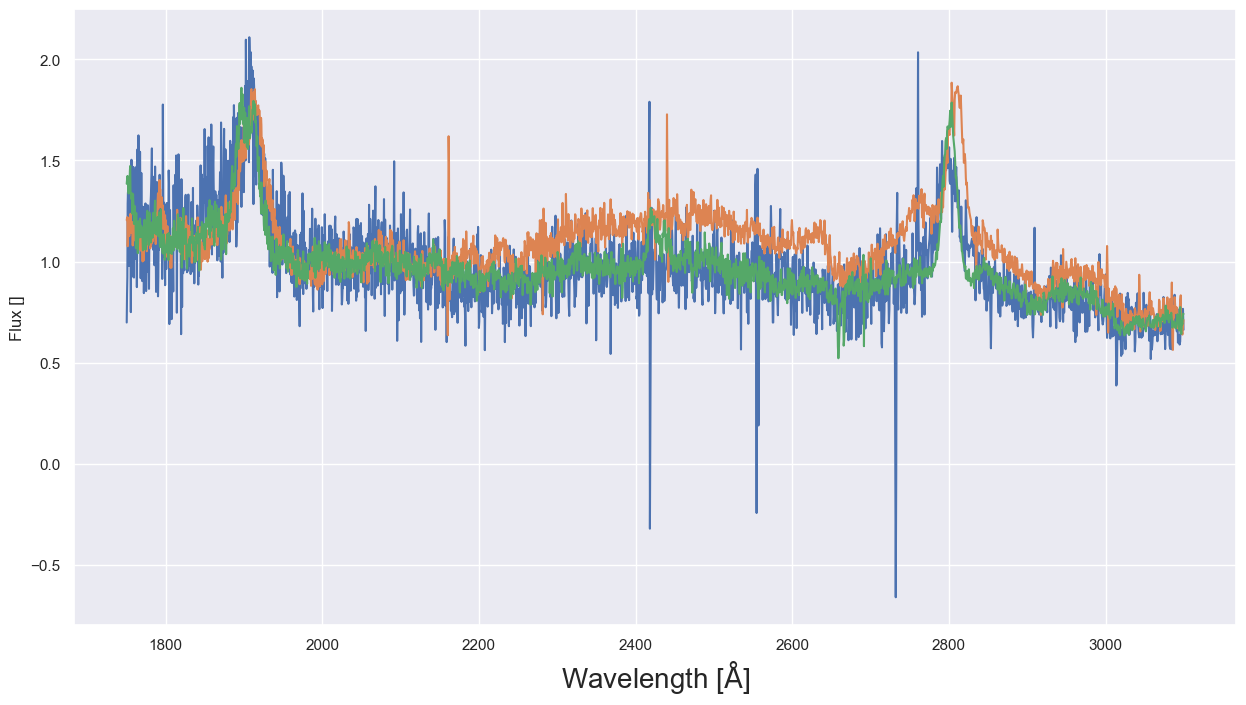

In [23]:
plt.figure(figsize=(15,8))
plt.plot(wavelength,data[0].data[10,:],color='C0')
plt.plot(wavelength,data[0].data[701,:],color='C1')
plt.plot(wavelength,data[0].data[100,:],color='C2')
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux []')

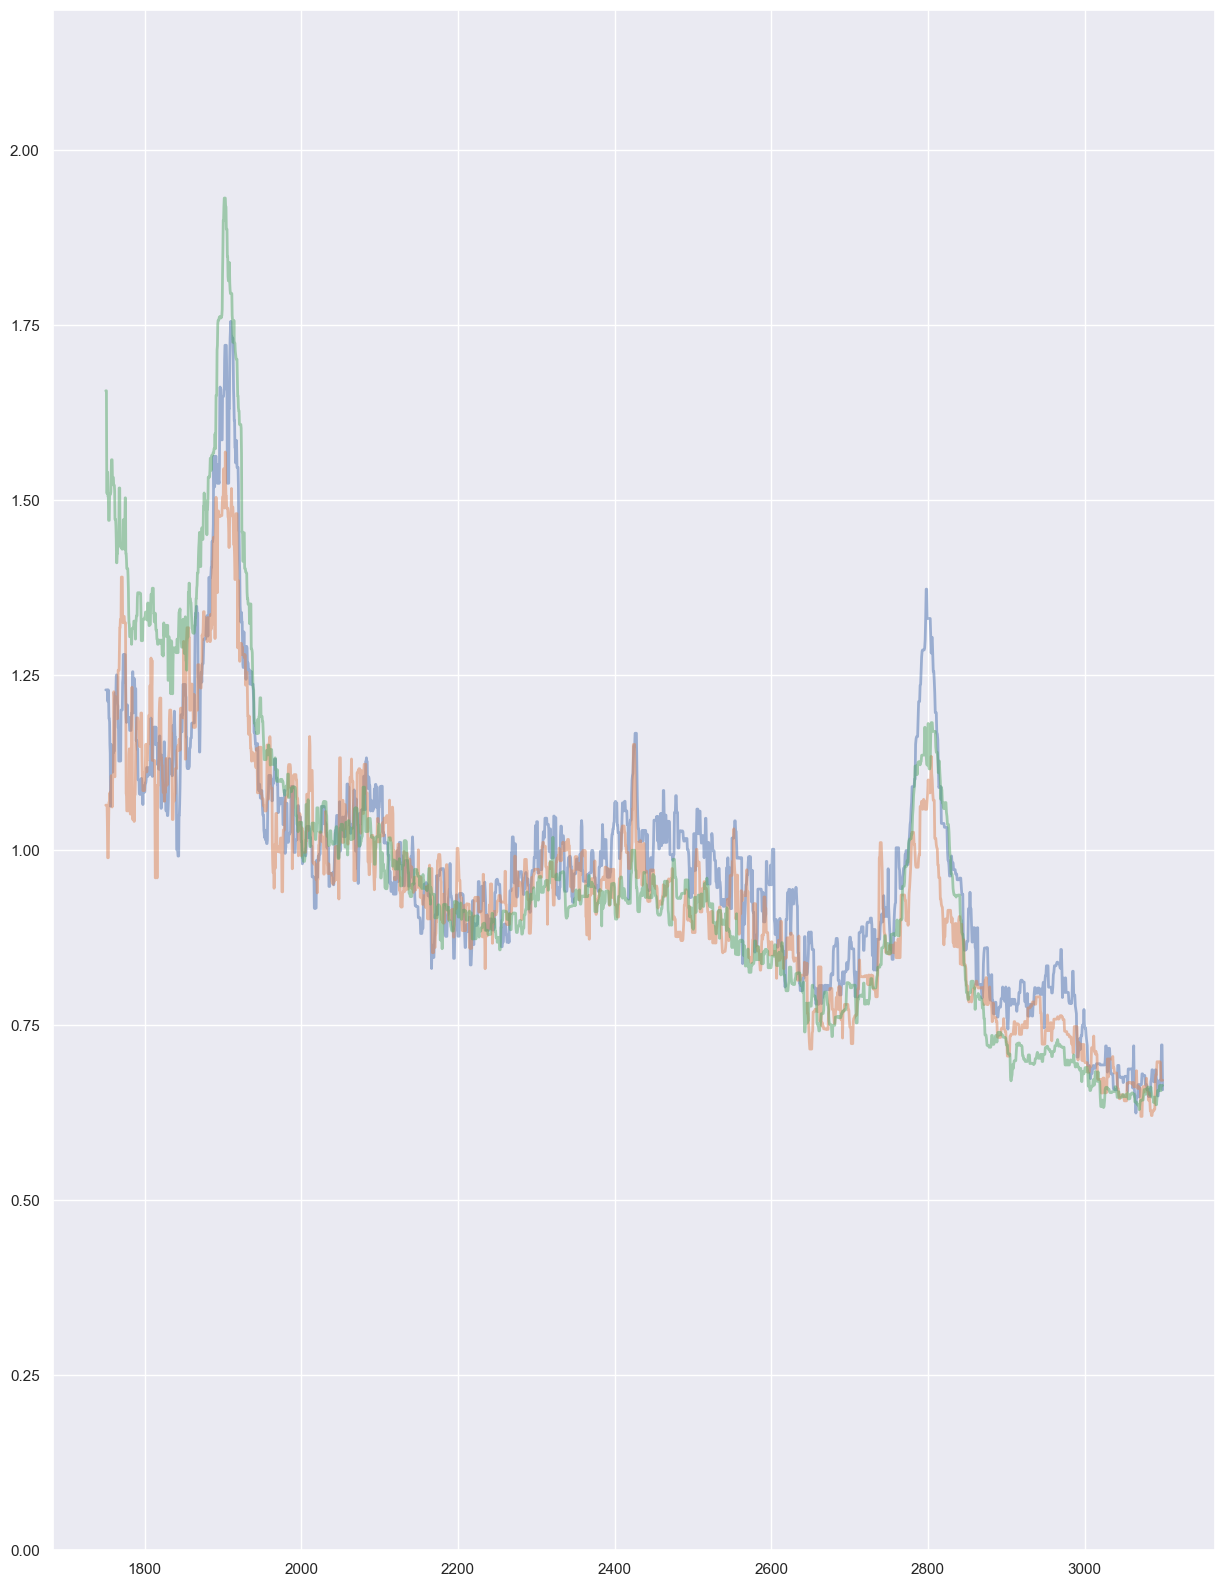

In [29]:
import scipy.ndimage as sn
smooth_spectra = np.zeros((len(data[0].data),len(data[0].data[0])))
for i_object in range(0,len(data[0].data)):
    smooth_spectra[i_object] = sn.median_filter(data[0].data[i_object],10)

plt.figure(figsize=(15,20))
#plt.plot(10**data[2].data,data[0].data[10,:])
for i in range(0,3):
    #plt.subplot(10,1,i+1)
    plt.plot(10**data[2].data,smooth_spectra[i,:],lw=2,alpha=0.5)
    plt.ylim(0,2.2)

### 1. Do the PCA and explore the outputs!

Follow the code above!

1. Data structure matrix [i_object, i_feature]


2. pca = PCA(n_components=10)
   
   pca.fit(matrix)
   
   
3. plot wavelength, pca.mean_


4. plot wavelength, pca.components_[i] i=0,1,2,3,4,5,6

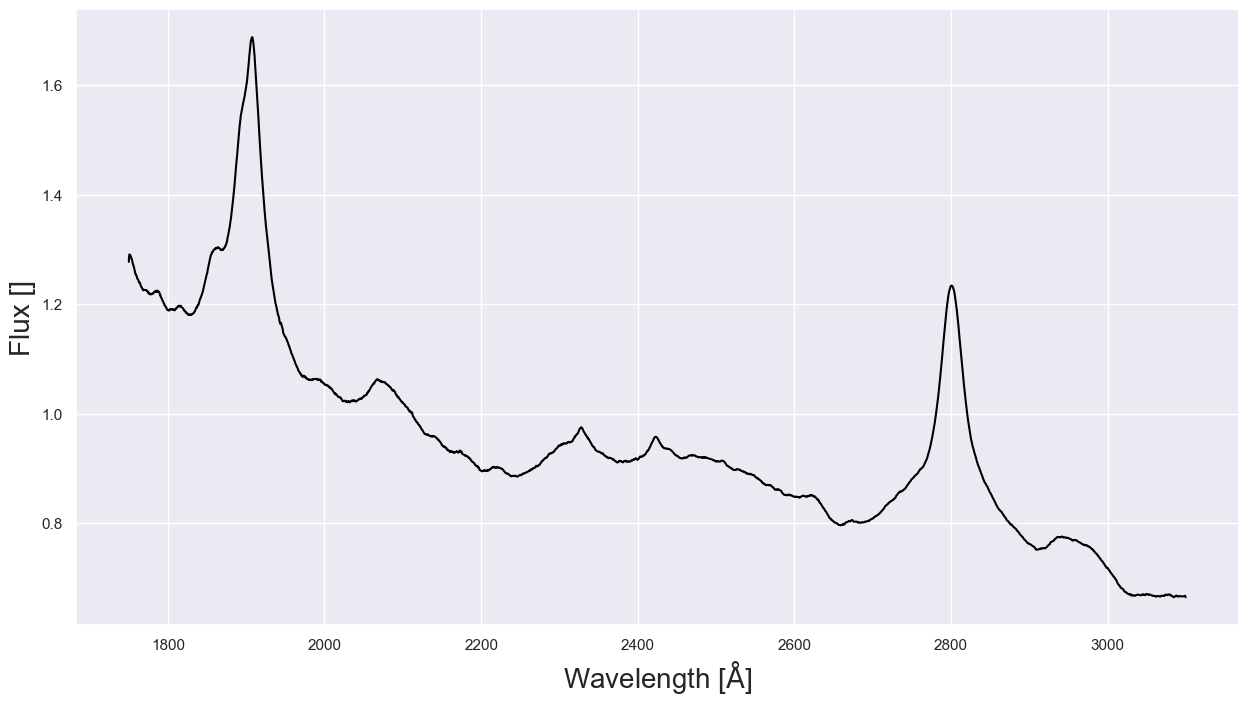

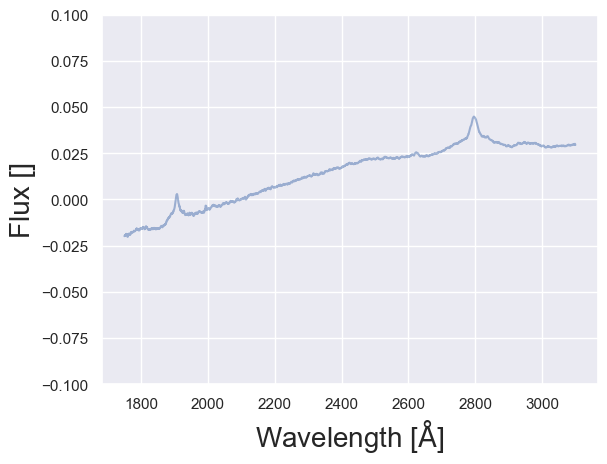

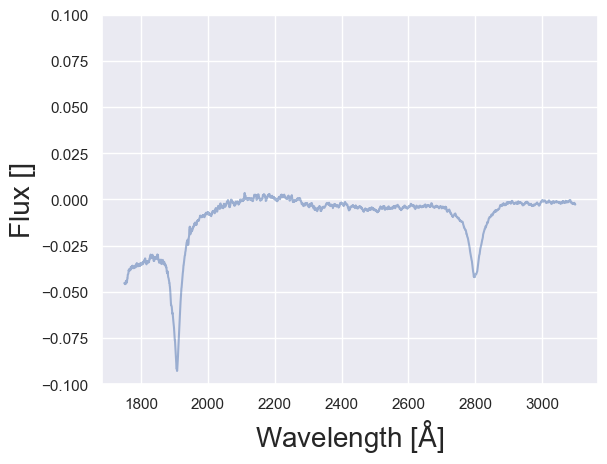

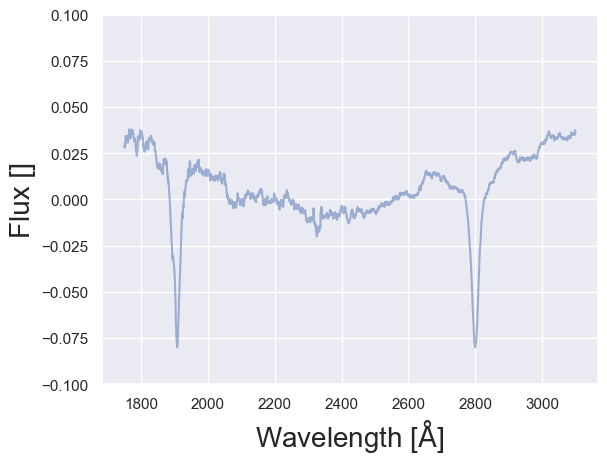

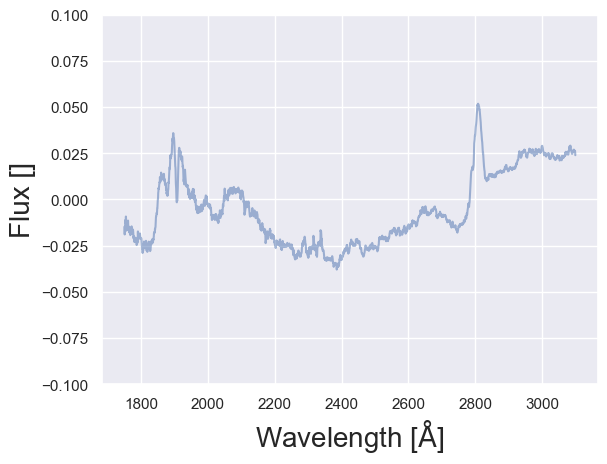

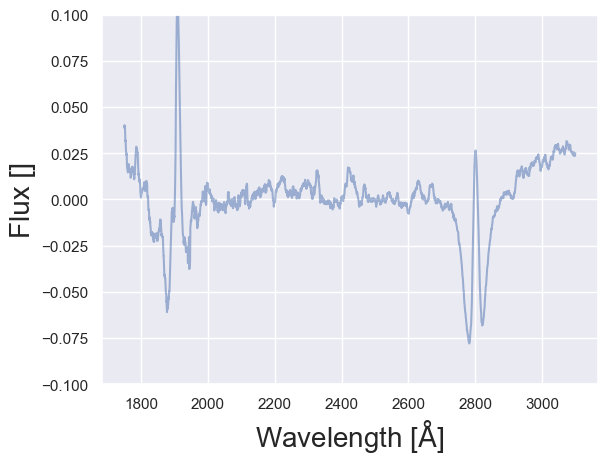

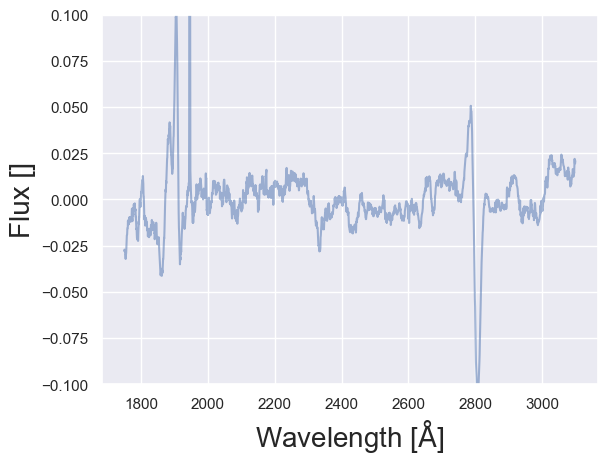

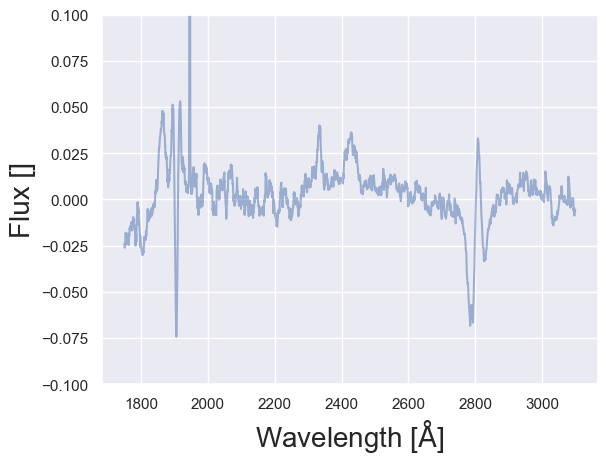

In [89]:
### 1. Do the PCA and explore the outputs!
"""
Follow the code above!
#1. Data structure matrix [i_object, i_feature]
#2. pca = PCA(n_components=10)
   #pca.fit(matrix)
3. plot wavelength, pca.mean_
4. plot wavelength, pca.components_[i] i=0,1,2,3,4,5,6
"""

X_matrix = smooth_spectra 
pca = PCA(n_components=10)
pca.fit(X_matrix)
# pca.components = eigenvectors

plt.figure(figsize=(15,8))
plt.plot(wavelength,pca.mean_,color='black')
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux []',fontsize=20)
plt.show()

for i in range(0,7):
   plt.plot(wavelength,pca.components_[i],alpha=0.5)
   plt.ylim(-0.1,0.1)
   plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
   plt.ylabel('Flux []',fontsize=20)
   plt.show()



### 2. Plot the coeff 0 (x-axis) and coeff 1 (y-axis) distribution and check the spectra of the outliers. 

coefficients = pca.transform(matrix)

(10, 2483)


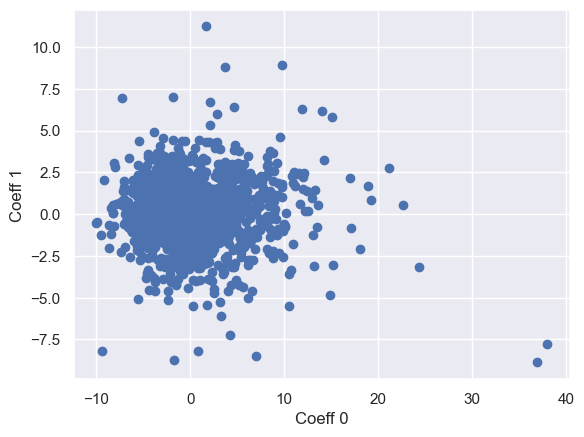

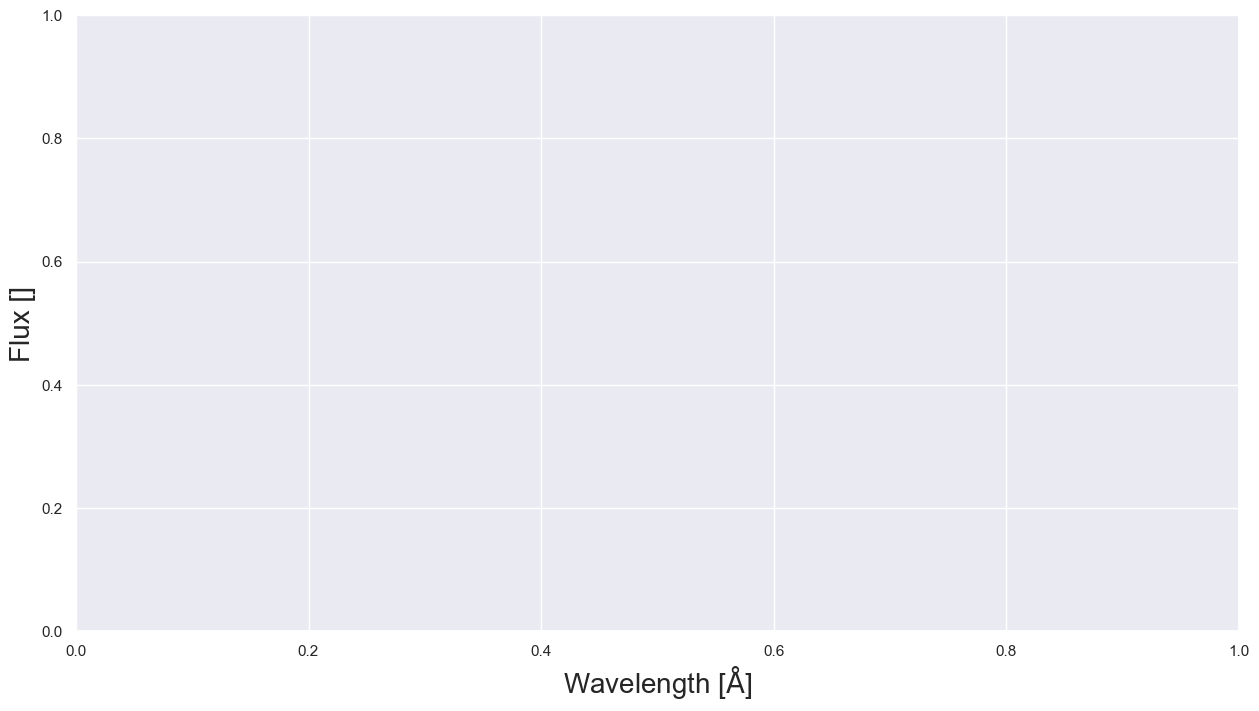

In [107]:
from sklearn.cluster import KMeans

### 2. Plot the coeff 0 (x-axis) and coeff 1 (y-axis) distribution and check the spectra of the outliers. 

coefficients = pca.transform(X_matrix)
print(pca.components_.shape)
plt.scatter(coefficients[:,0],coefficients[:,1])
plt.xlabel('Coeff 0')
plt.ylabel('Coeff 1')

# Identify outliers based on the first PCA coefficient
outliers = np.where(coefficients[:, 1] > 30)




# Extract the coefficients of the outliers
outliers_coeff = coefficients[outliers]

# Extract the spectra of the outliers from the original data
outlier_spectra = X_matrix[outliers[0]]

plt.figure(figsize=(15,8))
for i in range(0,len(outliers[0])):
    plt.plot(wavelength,X_matrix[outliers[0][i]],alpha=0.5)
plt.xlabel('Wavelength [$\\rm \\AA$]',fontsize=20)
plt.ylabel('Flux []',fontsize=20)
plt.show()



### 3. Reconstruct the spectra of the outliers with the PCA eigenspectra. 

In [1]:


# Reconstruct the outlier spectra using PCA components and coefficients
outlier_reconstruct = np.zeros(outlier_spectra.shape)
for i_object in range(len(outliers_coeff)):
    outlier_reconstruct[i_object] = (
        outliers_coeff[i_object, 0] * pca.components_[0] +
        outliers_coeff[i_object, 1] * pca.components_[1] +
       
        pca.mean_
    )

# Plot the reconstructed outlier spectra
wavelength = 10**data[2].data  # Assuming data[2].data contains the wavelength information

plt.figure(figsize=(15, 8))
for i in range(len(outlier_reconstruct)):  # Plot the reconstructed spectra for each outlier
    plt.plot(wavelength, outlier_reconstruct[i, :], lw=2, alpha=0.5, label=f'Reconstructed Outlier {i+1}')
plt.xlabel('Wavelength [$\\rm \\AA$]', fontsize=20)
plt.ylabel('Flux [ ]', fontsize=20)
plt.legend()
plt.show()


NameError: name 'np' is not defined

# -------------------------------------------

In [45]:
# Exercise 2
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape


(1797, 64)

[[ 0.  0.  3. 10. 14.  3.  0.  0.]
 [ 0.  8. 16. 11. 10. 13.  0.  0.]
 [ 0.  7. 14.  0.  1. 15.  2.  0.]
 [ 0.  2. 16.  9. 16. 16.  1.  0.]
 [ 0.  0. 12. 16. 15. 15.  2.  0.]
 [ 0.  0. 12. 10.  0.  8.  8.  0.]
 [ 0.  0.  9. 12.  4.  7. 12.  0.]
 [ 0.  0.  2. 11. 16. 16.  9.  0.]]


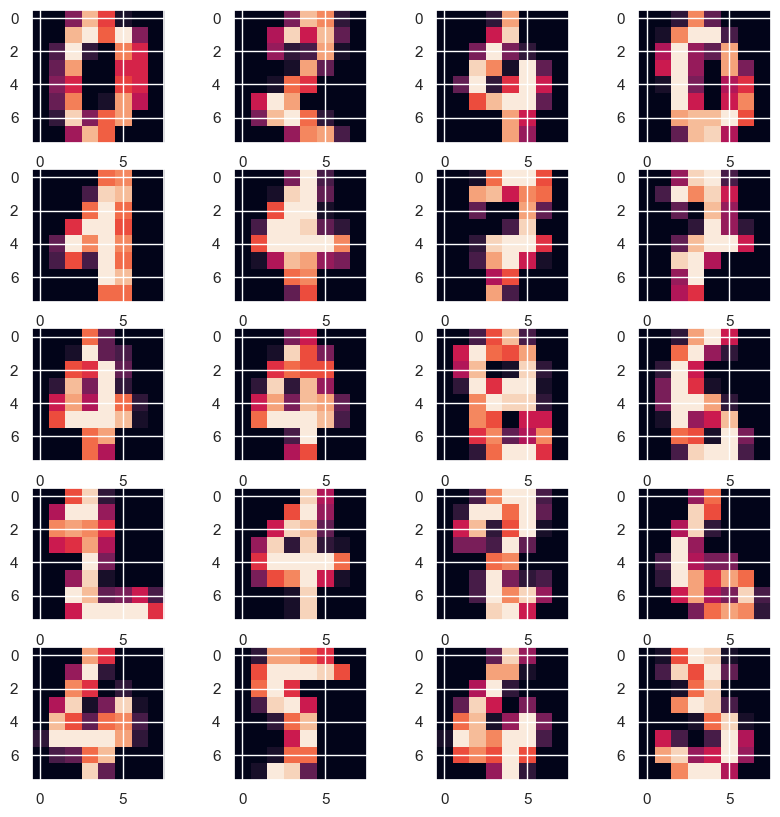

In [49]:
plt.figure(figsize=(10,10))
for i in range(0,20):
    plt.subplot(5,4,i+1)
    plt.imshow(digits.data[i*50].reshape(8,8))
print(digits.data[500].reshape(8,8))

### Do PCA with this dataset
### Get the coeff

(1797, 10)


Text(0, 0.5, 'Coeff 1')

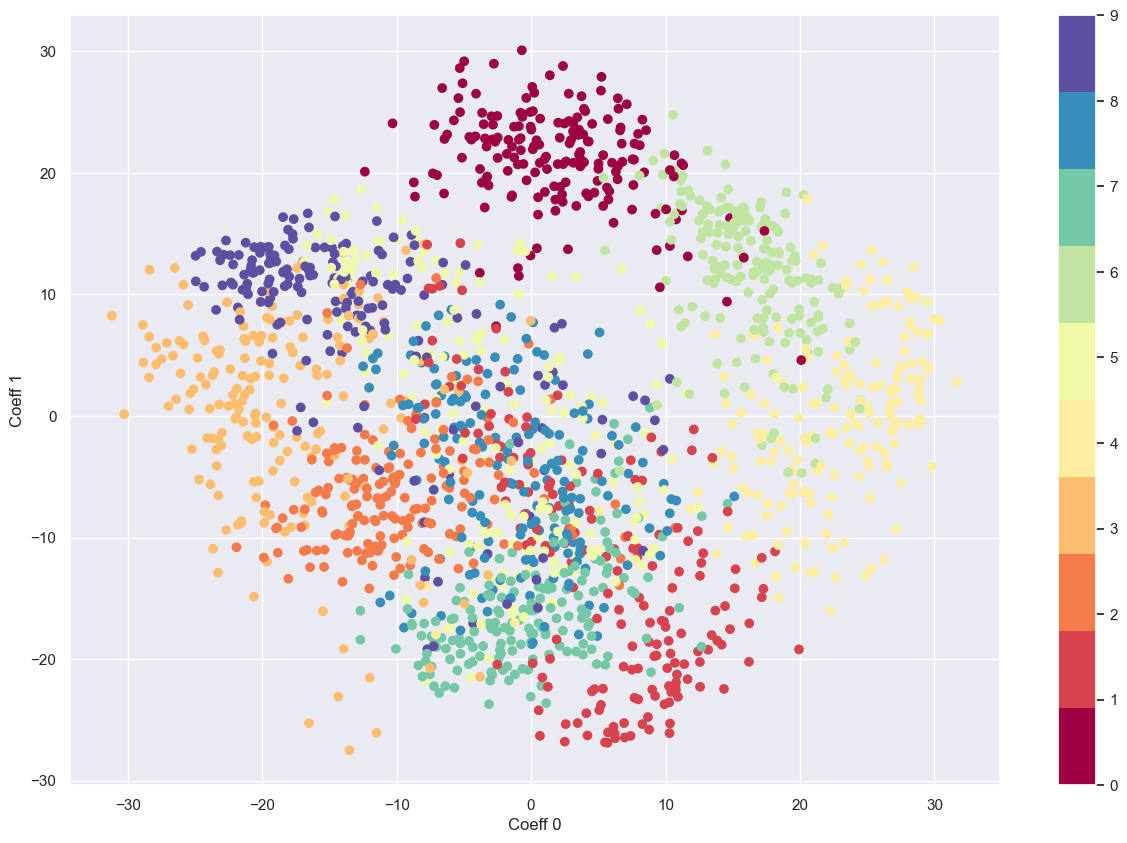

In [48]:
coeff = pca.fit_transform(digits.data)
print(coeff.shape)

plt.figure(figsize=(15,10))
plt.scatter(coeff[:,0],coeff[:,1],c=digits.target,cmap=plt.cm.get_cmap('Spectral', 10))
plt.colorbar()
plt.xlabel('Coeff 0')
plt.ylabel('Coeff 1')
